In [23]:
#Import libraries and Load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_style("whitegrid")
%matplotlib inline
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [24]:
#Exploring data structure
print("Shape:",df.shape)
df.dtypes

Shape: (891, 12)


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [25]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [26]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [27]:
#Identify patterns and trends
print("Survival Rate by Sex:")
print(df.groupby("Sex")["Survived"].mean())

print("\n Survival Rate by Pclass")
print(df.groupby("Pclass")["Survived"].mean())

print("\n Survival Rate by Embark")
print(df.groupby("Embarked")["Survived"].mean())

Survival Rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

 Survival Rate by Pclass
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

 Survival Rate by Embark
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [28]:
# Engineer a FamilySize feature and check survival by family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
print(df.groupby('FamilySize')['Survived'].mean())

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


In [29]:
#High light fare pay check anomalies
df.nlargest(5,"Fare")[["Name","Fare","Pclass"]]

,Name,Fare,Pclass
258,"Ward, Miss. Anna",512.3292,1
679,"Cardeza, Mr. Thomas Drake Martinez",512.3292,1
737,"Lesurer, Mr. Gustave J",512.3292,1
27,"Fortune, Mr. Charles Alexander",263.0000,1
88,"Fortune, Miss. Mabel Helen",263.0000,1


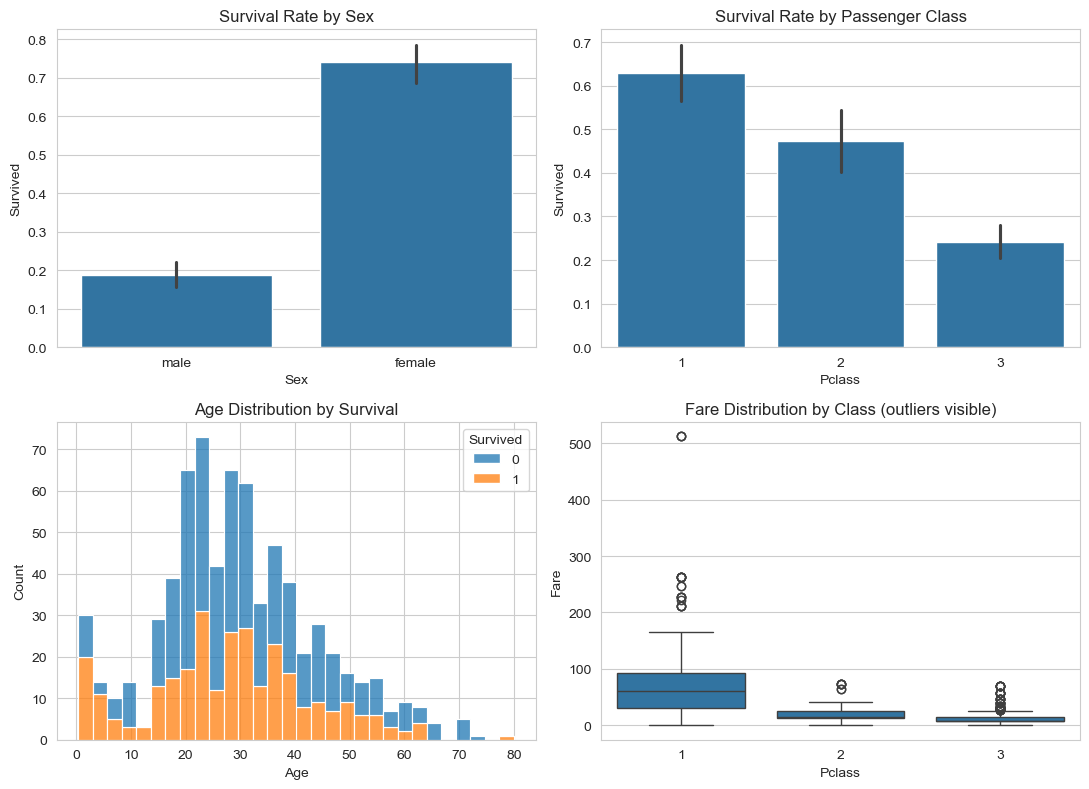

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Survival Rate by Sex')

sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[0, 1])
axes[0, 1].set_title('Survival Rate by Passenger Class')

sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution by Survival')

sns.boxplot(data=df, x='Pclass', y='Fare', ax=axes[1, 1])
axes[1, 1].set_title('Fare Distribution by Class (outliers visible)')

plt.tight_layout()
plt.show()

In [31]:
# H1: Sex and Survival are related
contingency_sex = pd.crosstab(df['Sex'], df['Survived'])
chi2, p, dof, exp = stats.chi2_contingency(contingency_sex)
print(f"H1: Sex vs Survival -> chi2={chi2:.2f}, p={p:.2e}")

# H2: Pclass and Survival are related
contingency_class = pd.crosstab(df['Pclass'], df['Survived'])
chi2, p, dof, exp = stats.chi2_contingency(contingency_class)
print(f"H2: Pclass vs Survival -> chi2={chi2:.2f}, p={p:.2e}")

H1: Sex vs Survival -> chi2=260.72, p=1.20e-58
H2: Pclass vs Survival -> chi2=102.89, p=4.55e-23


In [19]:
# H3: Survivors paid higher fares on average
fare_survived = df[df['Survived'] == 1]['Fare'].dropna()
fare_died = df[df['Survived'] == 0]['Fare'].dropna()
t, p = stats.ttest_ind(fare_survived, fare_died, equal_var=False)
print(f"H3: Fare (survived vs died) -> t={t:.2f}, p={p:.2e}")
print(f"   mean fare survived={fare_survived.mean():.2f}, mean fare died={fare_died.mean():.2f}")

# H4: Age differs between survivors and non-survivors
age_survived = df[df['Survived'] == 1]['Age'].dropna()
age_died = df[df['Survived'] == 0]['Age'].dropna()
t, p = stats.ttest_ind(age_survived, age_died, equal_var=False)
print(f"H4: Age (survived vs died) -> t={t:.2f}, p={p:.3f}")

H3: Fare (survived vs died) -> t=6.84, p=2.70e-11
   mean fare survived=48.40, mean fare died=22.12
H4: Age (survived vs died) -> t=-2.05, p=0.041


In [20]:
#Detect data issues and problems
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(1)
print("Missing values:")
print(missing[missing > 0])
print("\nPercent missing:")
print(missing_pct[missing_pct > 0])

Missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64

Percent missing:
Age         19.9
Cabin       77.1
Embarked     0.2
dtype: float64


In [21]:
print("Duplicate rows:", df.duplicated().sum())

# Outlier detection on Fare using the IQR method
Q1, Q3 = df['Fare'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df[(df['Fare'] < Q1 - 1.5 * IQR) | (df['Fare'] > Q3 + 1.5 * IQR)]
print(f"Fare outliers (IQR method): {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")

print("Fare == 0 (likely free passage / data entry issue):", (df['Fare'] == 0).sum())

Duplicate rows: 0
Fare outliers (IQR method): 116 rows (13.0%)
Fare == 0 (likely free passage / data entry issue): 15
